# Optimising the Wind in Seismic Signals

## 0. Imports

In [ ]:
# For Configuration File
import yaml
from pathlib import Path
import importlib

config_path = ###

# Load config File
with open(config_path, "r") as f:
    config = yaml.safe_load(f)

# Variables
name = config["name"]
seismic_path = config["seismic_data_path"]
seismic_data = Path(config['seismic_data_path'])
align_module = config['align_module']
process_module = config['process_module']
wind_module = config['wind_module']

# obspy GitHub:
# https://github.com/obspy/obspy
from obspy import UTCDateTime as UTC

# seismic-data-quality GitHub: 
# https://github.com/Ramirezs873/seismic-data-quality
spec1 = importlib.util.spec_from_file_location("process", process_module)
process = importlib.util.module_from_spec(spec1)
spec1.loader.exec_module(process)

# seismic-sensor-anlysis GitHub:
# https://github.com/Ramirezs873/seismic-sensor-analysis
spec2 = importlib.util.spec_from_file_location("align", align_module)
align = importlib.util.module_from_spec(spec2)
spec2.loader.exec_module(align)

# seismic-weather GitHub:
# https://github.com/Ramirezs873/seismic-weather
spec3 = importlib.util.spec_from_file_location("wind", wind_module)
wind = importlib.util.module_from_spec(spec3)
spec3.loader.exec_module(wind)

aws_path = config['aws_data_path']

## 1. Gather Data

### 1.1 AWS Data

In [6]:
# Load Data
skiway = wind.read_data(path=aws_path, station_code='300060', id_code='55510926053')
WS = wind.wind_speed(skiway, year = 2022, month = 12, day = (25), hour = (0,12), plot = False)

### 1.2 Seismic Data

In [7]:
CWA = align.seismic_data('AUSPASS', 'Z9', 'CWA81', "*", "*", UTC(2022, 12, 25, 0, 0,0), UTC(2022, 12, 25, 13, 0, 0), user1='Z9', password1='peach25', config=config)

File not found. Downloading data
Saved to: C:\Users\simon\Desktop\UTAS\Honours Research\Workspace\station_data_Z9_5stations_2022-12-25.mseed


## 2. Seismic preprocessing

### 2.1 Rotation Correction

In [8]:
CWA_rotated = align.rotate_stream(CWA, ['HHN'], ['HHE'], ['HHZ'], [-1.34])

Processing Z9.CWA81....


### 2.2 Amplitude Correction

In [9]:
CWA_amplitude_corrected = process.amplitude_correction(wave_dict = CWA_rotated, 
                                                       NS_channel = ['HHN'], 
                                                       EW_channel = ['HHE'], 
                                                       Z_channel = ['HHZ'], 
                                                       sensitivity = 2.994697576134245E8, 
                                                       NS_correction_factor = [1/0.72], 
                                                       EW_correction_factor = [1/0.67], 
                                                       Z_correction_factor = [1/0.58])

Processing Z9.CWA81....


### 2.3 Demean, Detrend

In [10]:
CWA_dd = align.demean_detrend(CWA_amplitude_corrected)

### 2.4 Taper

In [11]:
CWA_hann = align.apply_window(CWA_dd, max_length=300)

## 3. Montecarlo Test on Optimal Filter Frequencies 

### 3.1 To Maximise Similarity between SNR and Wind Speed

In [12]:
monte_snr = wind.montecarlo_optimal_snr(wind_speed = WS, 
                            wave_dict = CWA_hann, 
                            freq_range = (10,15),
                            n_iterations = 1, 
                            NS_channel = ["HHN"],
                            EW_channel = ["HHE"],
                            Z_channel = ["HHZ"])

Processing Z9.CWA81....
Completed 1/1 iterations

Best frequency range for Z9.CWA81.: 14 - 15 Hz
Z R²: 0.1722
NS R²: 0.2587
EW R²: 0.2965
Average R²: 0.2425


### 3.2 To Maximise Similarity between Power and Wind Speed

In [18]:
monte_P = wind.power_wind_monte(wind_speed = WS, 
                            wave_dict = CWA_hann, 
                            fmin = 10, 
                            fmax = 11,
                            csv = True,
                            config = config)

Completed Iteration 10Hz-11Hz. AVG R Sqaured = 0.05261660036278785

Best frequency range for Z9.CWA81.: 10 - 11 Hz
Z R²: 0.0720
NS R²: 0.0427
EW R²: 0.0432
Average R²: 0.0526
Results saved to monte_resutls.csv


## 4. Plot the Best Result from Part 3.

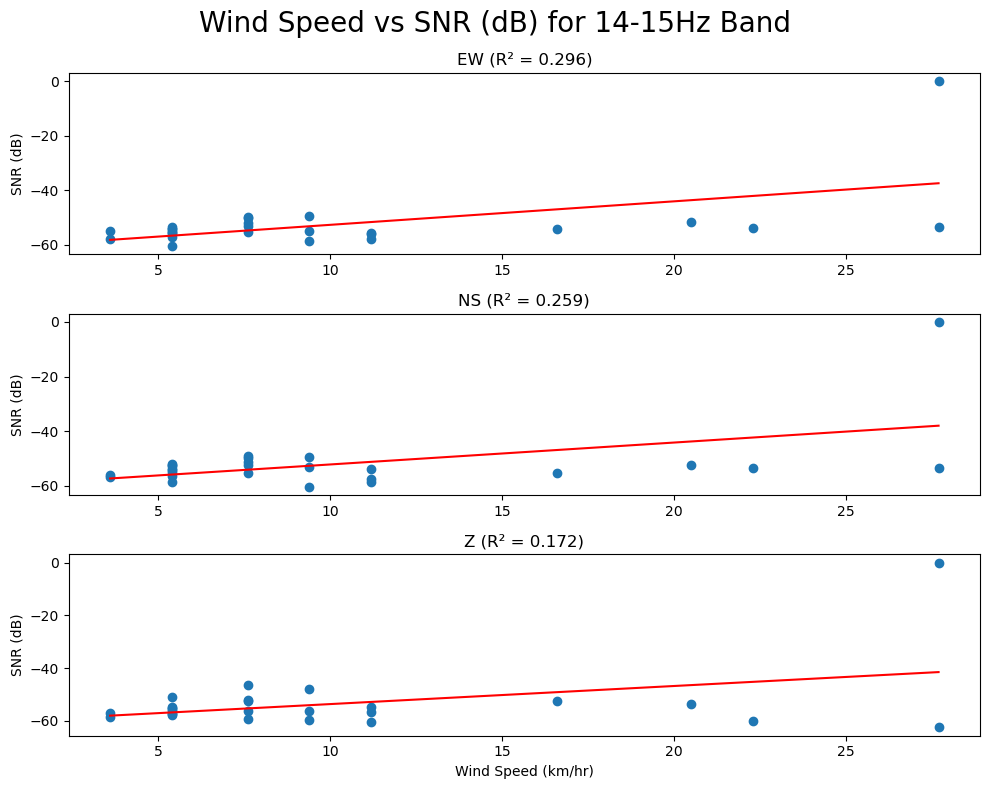

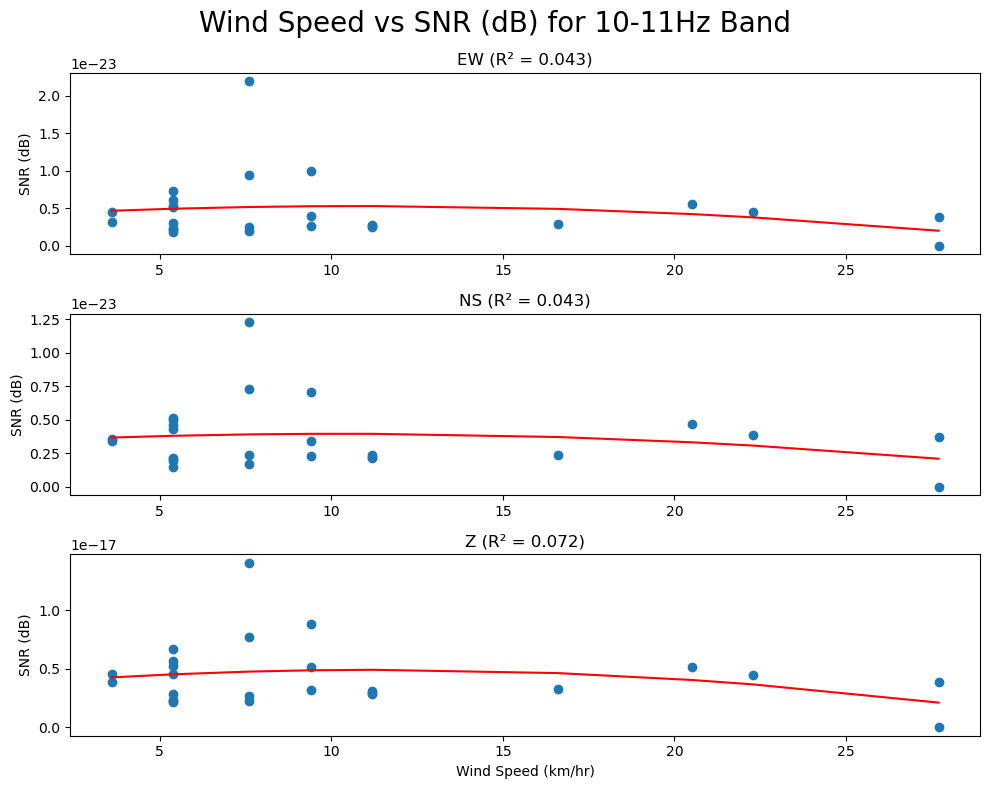

In [ ]:
wind.plot_statistics(monte_snr[0]) #snr is currently calculating a linear fit
wind.plot_statistics(monte_P[0][0]) #P is currently calculating a quadratic fit